<a href="https://colab.research.google.com/github/opherdonchin/BayesShortCourse/blob/main/golf/08_learn_overshoot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Golf putting 8 — Learn overshoot too

As a final expansion, treat both the acceptable distance tolerance and the intended overshoot as uncertain parameters, each with an informative but non-degenerate prior.

## Setup

This course pins PyMC and the modular ArviZ packages for reproducibility because their APIs can change across major versions.

In [2]:
%pip install -q \
    "pymc==6.3.2" \
    "arviz-base==1.3.0" \
    "arviz-stats==1.3.2" \
    "arviz-plots[matplotlib]==1.3.1"

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz_plots as azp
import arviz_stats as azs

RANDOM_SEED = 20260923
azp.style.use("arviz-variat")

print("PyMC:", pm.__version__)
print("arviz-plots:", azp.__version__)
print("arviz-stats:", azs.__version__)

DATA_BASE = "https://raw.githubusercontent.com/opherdonchin/BayesShortCourse/main/golf/data"
golf = pd.read_csv(f"{DATA_BASE}/broadie_2018_putting.csv")
golf["rate"] = golf["made"] / golf["attempts"]

BALL_RADIUS_FT = (1.68 / 2) / 12
CUP_RADIUS_FT = (4.25 / 2) / 12

golf

PyMC: 6.3.2
arviz-plots: 1.3.1
arviz-stats: 1.3.2


,distance_ft,attempts,made,rate
0,0.28,45198,45183,0.999668
1,0.97,183020,182899,0.999339
2,1.93,169503,168594,0.994637
3,2.92,113094,108953,0.963384
4,3.93,73855,64740,0.876582
5,4.94,53659,41106,0.766060
6,5.94,42991,28205,0.656068
7,6.95,37050,21334,0.575816
8,7.95,33275,16615,0.499324
9,8.95,30836,13503,0.437897


In [4]:
def plot_rate(draws, data, title, *, median_label="median", show_observed=True, ylim=(-0.05, 1.05), show_bounds=False):
    """Plot a probability/rate relationship against continuous putting distance."""
    x = data["distance_ft"].to_numpy()
    curve_dim = next(dim for dim in draws.dims if dim not in ("chain", "draw"))
    order = np.argsort(x)
    draws = draws.isel({curve_dim: order})
    x = x[order]

    median = draws.median(dim=("chain", "draw"))
    interval = draws.azstats.hdi(prob=0.90)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.fill_between(
        x,
        interval.sel(ci_bound="lower"),
        interval.sel(ci_bound="upper"),
        alpha=0.22,
        label="90% HDI",
    )
    ax.plot(x, median, label=median_label)
    if show_observed:
        ax.scatter(x, data["rate"].to_numpy()[order], s=30, color="black", label="observed")
    if show_bounds:
        ax.axhline(0, color="0.6", linewidth=0.8, linestyle="--")
        ax.axhline(1, color="0.6", linewidth=0.8, linestyle="--")
    ax.set(
        xlabel="Distance from hole (feet)",
        ylabel="Proportion made",
        title=title,
    )
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.legend(fontsize=8, frameon=False)
    return ax

def plot_residuals(idata, data, var_name="p_base", title="Residuals"):
    """Plot observed minus posterior-median mechanistic probability."""
    fitted = idata["posterior"][var_name].median(dim=("chain", "draw")).to_numpy()
    x = data["distance_ft"].to_numpy()
    residual = data["rate"].to_numpy() - fitted
    order = np.argsort(x)

    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.axhline(0, linestyle="--", linewidth=1)
    ax.plot(x[order], residual[order], marker="o")
    ax.set(
        xlabel="Distance from hole (feet)",
        ylabel="Observed − fitted probability",
        title=title,
    )
    return ax

## Model revision

$$
\text{tolerance}\sim\operatorname{LogNormal}(\log 3,0.2),
\qquad
\text{overshoot}\sim\operatorname{LogNormal}(\log 1,0.2).
$$

The aim is now as much inferential as predictive: can these two physical quantities be learned separately from the aggregated putting data?

In [5]:
coords = {"obs_id": golf["distance_ft"].to_numpy()}

with pm.Model(coords=coords) as model:
    distance = pm.Data("distance", golf["distance_ft"].to_numpy(), dims="obs_id")
    attempts = pm.Data("attempts", golf["attempts"].to_numpy(), dims="obs_id")
    sigma_angle_deg = pm.LogNormal("sigma_angle_deg", mu=np.log(2), sigma=0.7)
    sigma_distance = pm.LogNormal("sigma_distance", mu=np.log(0.10), sigma=0.7)
    distance_tolerance = pm.LogNormal("distance_tolerance", mu=np.log(3), sigma=0.2)
    overshot = pm.LogNormal("overshot", mu=np.log(1), sigma=0.2)

    sigma_angle_rad = sigma_angle_deg * np.pi / 180
    threshold_angle = pm.math.arcsin((CUP_RADIUS_FT - BALL_RADIUS_FT) / distance)
    p_angle = pm.Deterministic(
        "p_angle",
        2 * pm.math.invprobit(threshold_angle / sigma_angle_rad) - 1,
        dims="obs_id",
    )
    p_distance = pm.Deterministic(
        "p_distance",
        pm.math.invprobit(
            (distance_tolerance - overshot) / ((distance + overshot) * sigma_distance)
        )
        - pm.math.invprobit(
            -overshot / ((distance + overshot) * sigma_distance)
        ),
        dims="obs_id",
    )
    p_base = pm.Deterministic("p_base", p_angle * p_distance, dims="obs_id")
    sigma_epsilon = pm.HalfNormal("sigma_epsilon", sigma=0.02)
    epsilon = pm.Truncated(
        "epsilon",
        pm.Exponential.dist(lam=1 / sigma_epsilon),
        lower=0,
        upper=1,
        dims="obs_id",
    )
    p = pm.Deterministic("p", p_base * (1 - epsilon), dims="obs_id")

    made = pm.Binomial(
        "made",
        n=attempts,
        p=p,
        observed=golf["made"].to_numpy(),
        dims="obs_id",
    )

## Prior predictive check

Before fitting, ask what success rates the prior says are plausible across putting distance. The observed rates are shown only as a reference; they do not condition the prior.

In [6]:
with model:
    prior = pm.sample_prior_predictive(
        draws=500,
        var_names=["made"],
        random_seed=RANDOM_SEED,
    )

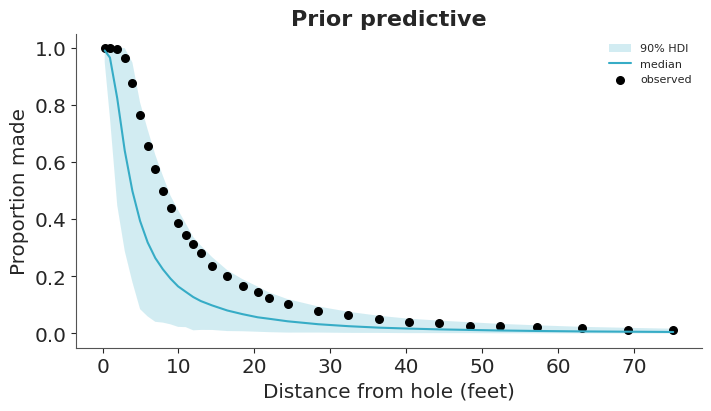

In [7]:
plot_rate(
    prior["prior_predictive"]["made"] / golf["attempts"].to_numpy(),
    golf,
    "Prior predictive",
);

## Fit and diagnose

Do not interpret the scientific fit until the sampler diagnostics are acceptable.

In [8]:
with model:
    idata = pm.sample(
        draws=1000,
        tune=1500,
        chains=4,
        target_accept=0.95,
        random_seed=RANDOM_SEED,
    )

print("Divergences:", int(idata["sample_stats"]["diverging"].sum().item()))
azs.summary(
    idata,
    var_names=['sigma_angle_deg', 'sigma_distance', 'sigma_epsilon', 'distance_tolerance', 'overshot'],
    ci_prob=0.90,
    ci_kind="hdi",
    round_to=2,
)

local_rhat = idata["posterior"]["epsilon"].azstats.rhat()
local_ess = idata["posterior"]["epsilon"].azstats.ess(method="bulk")
print(f"Worst epsilon R-hat: {float(local_rhat.max()):.3f}")
print(f"Smallest epsilon bulk ESS: {float(local_ess.min()):.0f}")

Output()

ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Divergences: 0
Worst epsilon R-hat: 1.033
Smallest epsilon bulk ESS: 126


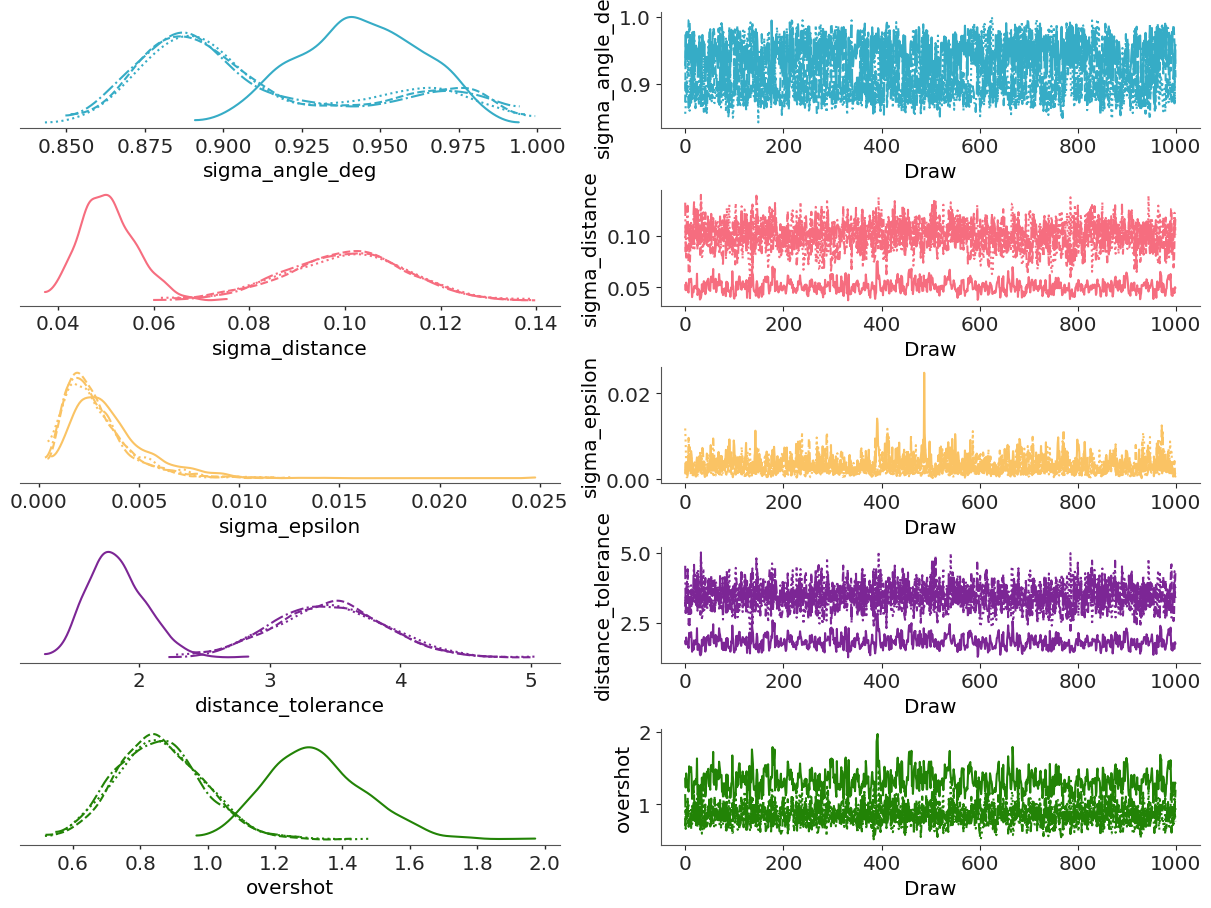

In [9]:
azp.plot_trace_dist(idata, var_names=['sigma_angle_deg', 'sigma_distance', 'sigma_epsilon', 'distance_tolerance', 'overshot']);

## Posterior fit

This plot shows posterior uncertainty in the continuous underlying mechanism $p_{base}(x)$ **before** the local discrepancy terms are applied. That distinction matters: the full model can fit the data by using local corrections even when the shared mechanism still has systematic structure.

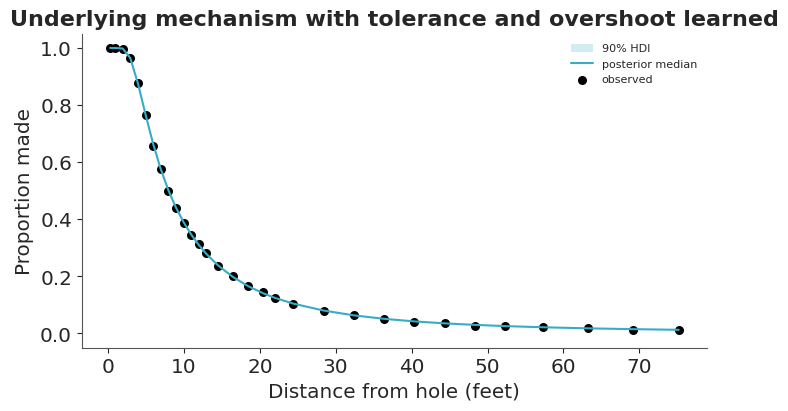

In [10]:
plot_rate(
    idata["posterior"]["p_base"],
    golf,
    "Underlying mechanism with tolerance and overshoot learned",
    median_label="posterior median",
);

## Posterior predictive check

Now generate new outcomes at the same putting distances from the **full fitted model**, including its local discrepancy terms. This uses the same graphical grammar as the prior predictive check; the difference is conditioning on the observed data.

In [11]:
with model:
    pm.sample_posterior_predictive(
        idata,
        var_names=["made"],
        extend_inferencedata=True,
        random_seed=RANDOM_SEED,
    )

Output()

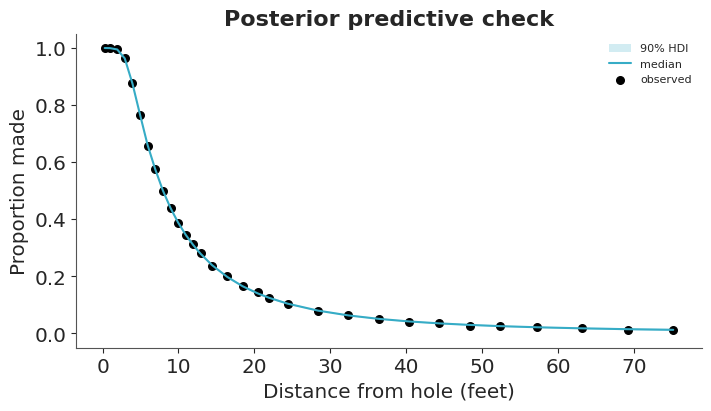

In [12]:
plot_rate(
    idata["posterior_predictive"]["made"] / golf["attempts"].to_numpy(),
    golf,
    "Posterior predictive check",
);

## Model criticism

These residuals deliberately compare the observations with $p_{base}(x)$, before the bin-specific discrepancy terms. They ask whether the shared mechanism still misses a systematic feature that the local corrections are masking.

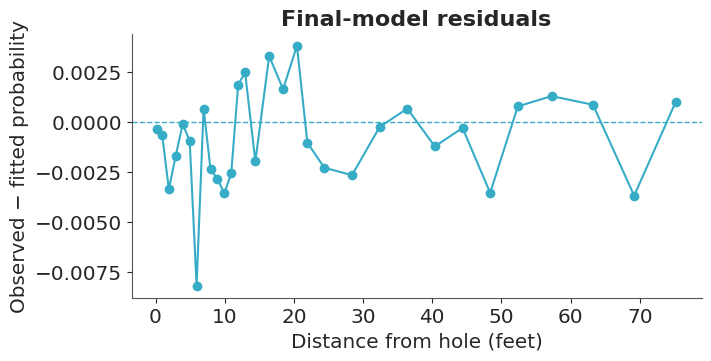

In [13]:
plot_residuals(idata, golf, var_name="p_base", title="Final-model residuals");

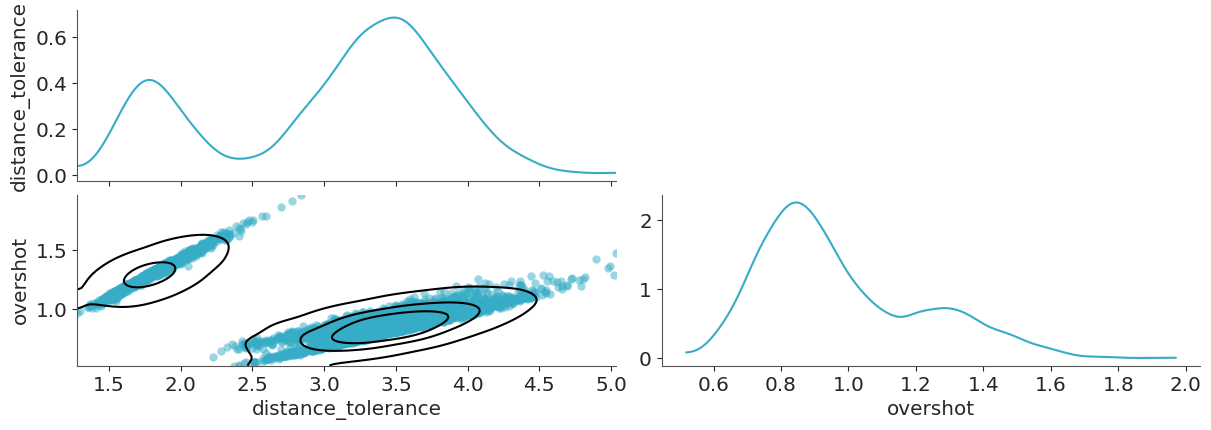

In [14]:
azp.plot_pair(
    idata,
    var_names=["distance_tolerance", "overshot"],
    marginal=True,
    marginal_kind="kde",
    triangle="lower",
    visuals={"scatter": True, "contour": True},
);

## Stop here

The predictive residuals are similar to the previous model, while the joint posterior reveals substantial dependence between tolerance and overshoot: the data identify combinations of them better than either quantity separately. This is a useful stopping point for the short course. The full *Bayesian Workflow* chapter continues with simplified discrepancy models and PSIS-LOO comparison; those are intentionally left out here so this example stays focused on **model building, checking, and revision**.